# Refactored Comparative Study of Pretrained CNN Models for Plant Disease Classification

This notebook is restructured for midterm presentation clarity.

**Models:** MobileNetV2, ResNet50, VGG16, EfficientNetB0, DenseNet121

Core logic, hyperparameters, and model architectures are unchanged.

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected: {gpus[0].name}")
else:
    print("WARNING: No GPU detected! Go to Runtime > Change runtime type > T4 GPU")

TensorFlow version: 2.19.0
GPU detected: /physical_device:GPU:0


In [ ]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50, VGG16, EfficientNetB0, DenseNet121
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    matthews_corrcoef,
)
warnings.filterwarnings('ignore')

## 2. Configuration

In [ ]:
# Paths for dataset (unchanged)
DRIVE_DATASET = "/content/drive/MyDrive/Plant_leave_diseases_dataset_with_augmentation"
LOCAL_DATASET = "/content/dataset"

# Fast copy to local disk (avoids slow Drive I/O during training)
if not os.path.exists(LOCAL_DATASET):
    print("Copying dataset from Drive to local disk...")
    !rm -rf /content/dataset
    !cp -r "/content/drive/MyDrive/Plant_leave_diseases_dataset_with_augmentation" /content/dataset
    print("Dataset copy completed")
else:
    print("Dataset already exists on local disk, skipping copy.")

DATASET_DIR = LOCAL_DATASET
IMG_SIZE = (224, 224)
BATCH_SIZE = 24
EPOCHS = 10
LEARNING_RATE = 1e-4

MODEL_SAVE_DIR = "/content/drive/MyDrive/models"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

print(f"Dataset: {DATASET_DIR}")
print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")

Dataset already exists on local disk, skipping copy.
Dataset: /content/dataset
Image size: (224, 224)
Batch size: 24
Epochs: 10


## 3. Common Data Pipeline

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print(f"Dataset loaded. Number of classes: {num_classes}")
print(class_names)

Found 53659 files belonging to 36 classes.
Using 42928 files for training.
Found 53659 files belonging to 36 classes.
Using 10731 files for validation.
Dataset loaded. Number of classes: 36
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves', 'Blueberry___healthy', 'Cherry___Powdery_mildew', 'Cherry___healthy', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_bl

## 3.1 Sample images from the dataset

Preview a batch so the notebook is not empty before training and you can show class diversity during evaluation.

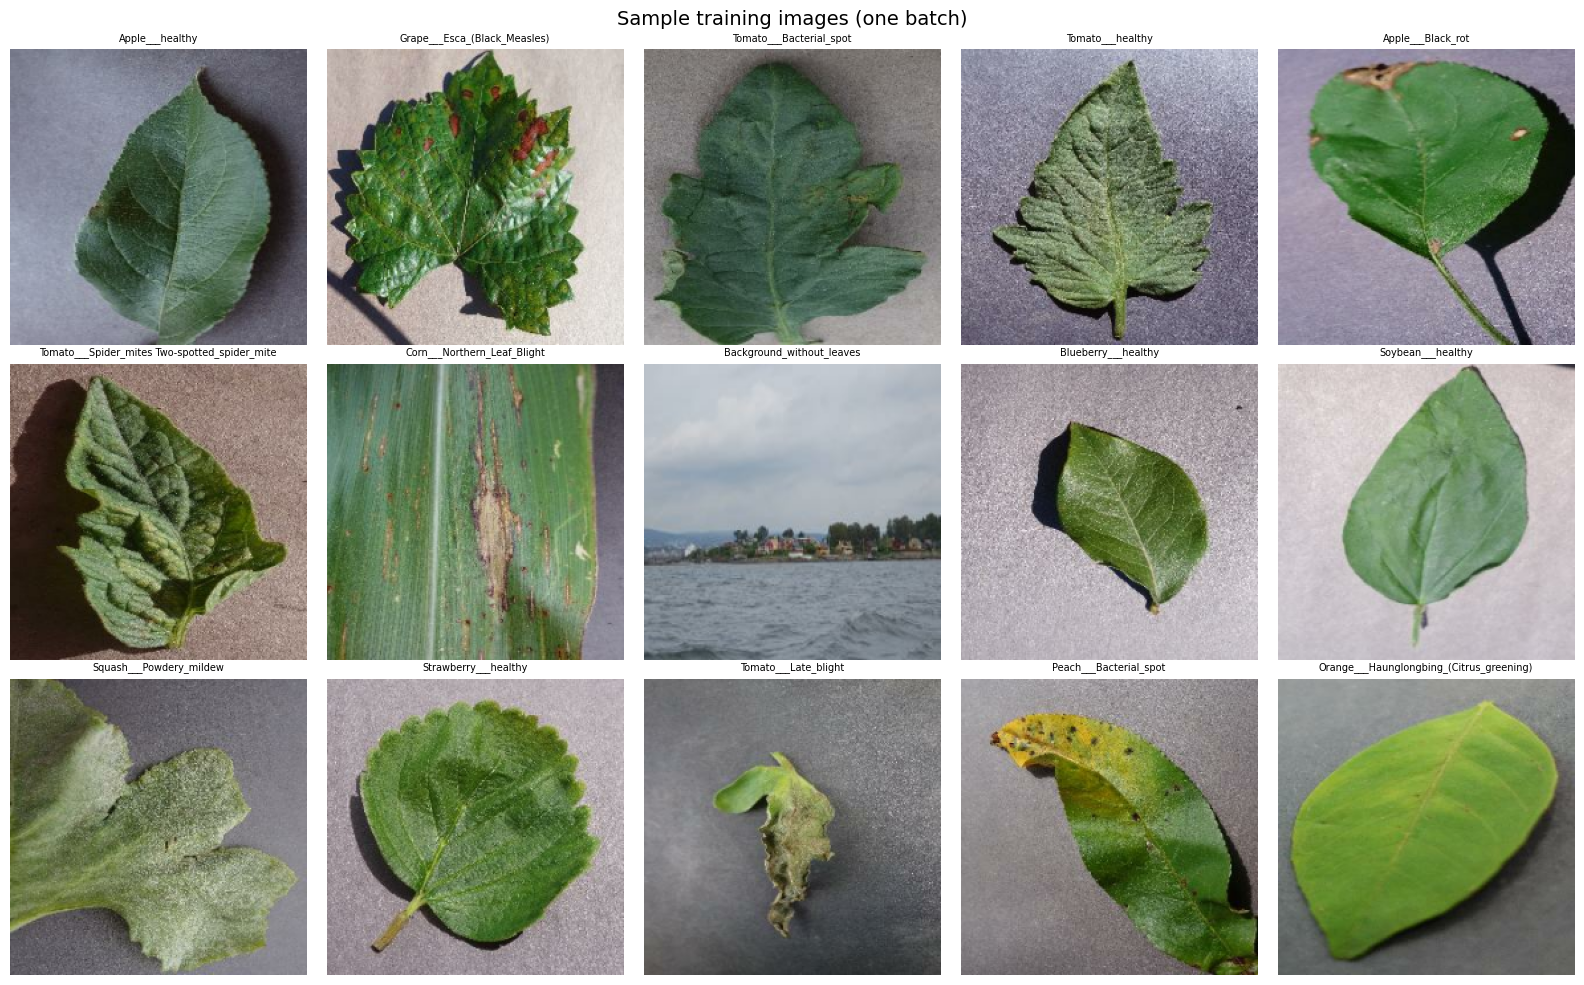

In [ ]:
plt.figure(figsize=(16, 10))
for images, labels in train_ds.take(1):
    n_show = min(15, len(images))
    for i in range(n_show):
        ax = plt.subplot(3, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])], fontsize=7)
        plt.axis("off")
plt.suptitle("Sample training images (one batch)", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Reusable Functions

In [ ]:
def build_model(model_name, num_classes, input_shape=(224, 224, 3)):
    backbone_config = {
        "MobileNetV2": {
            "model_fn": MobileNetV2,
            "preprocess": tf.keras.applications.mobilenet_v2.preprocess_input,
        },
        "ResNet50": {
            "model_fn": ResNet50,
            "preprocess": tf.keras.applications.resnet50.preprocess_input,
        },
        "VGG16": {
            "model_fn": VGG16,
            "preprocess": tf.keras.applications.vgg16.preprocess_input,
        },
        "EfficientNetB0": {
            "model_fn": EfficientNetB0,
            "preprocess": tf.keras.applications.efficientnet.preprocess_input,
        },
        "DenseNet121": {
            "model_fn": DenseNet121,
            "preprocess": tf.keras.applications.densenet.preprocess_input,
        },
    }

    config = backbone_config[model_name]
    base_model = config["model_fn"](
        weights="imagenet",
        include_top=False,
        input_shape=input_shape,
    )
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = config["preprocess"](inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name=model_name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train_model(model, train_ds, val_ds, model_name):
    print(f"Training {model_name}...")
    start_time = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)
    elapsed = time.time() - start_time
    print("Training completed")
    print(f"{model_name} training time: {elapsed/60:.2f} minutes")
    return history, elapsed


def evaluate_model(model, val_dataset):
    y_true = []
    y_pred = []

    for images, labels in val_dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = np.mean(y_true == y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "balanced_accuracy": balanced_acc,
        "mcc": mcc,
        "confusion_matrix": cm,
    }


def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Train', marker='o')
    axes[0].plot(history.history['val_accuracy'], label='Validation', marker='s')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train', marker='o')
    axes[1].plot(history.history['val_loss'], label='Validation', marker='s')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def generate_confusion_matrix(cm, class_names, model_name):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm_normalized,
        annot=False,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


def generate_classification_report(y_true, y_pred, class_names, model_name):
    print(f"\n{'='*60}")
    print(f"Classification Report - {model_name}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0, digits=4))


def append_comparison_row(model_name, model, results, training_time_sec):
    """Append one row to comparison_rows with extended metrics for the final table."""
    comparison_rows.append({
        "Model": model_name,
        "Val Accuracy": results["accuracy"],
        "Balanced Acc": results["balanced_accuracy"],
        "Precision (w)": results["precision"],
        "Recall (w)": results["recall"],
        "F1 (w)": results["f1_score"],
        "Precision (macro)": results["precision_macro"],
        "Recall (macro)": results["recall_macro"],
        "F1 (macro)": results["f1_macro"],
        "MCC": results["mcc"],
        "Training Time (min)": training_time_sec / 60.0,
        "Training Time (s)": training_time_sec,
        "Parameters": model.count_params(),
    })


histories = {}
trained_models = {}
training_times = {}
all_results = {}
comparison_rows = []

## 5. MobileNetV2


===== MobileNetV2 =====
Training MobileNetV2...
Epoch 1/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 89s 44ms/step - accuracy: 0.6995 - loss: 1.1248 - val_accuracy: 0.9245 - val_loss: 0.3114
Epoch 2/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 70s 39ms/step - accuracy: 0.8887 - loss: 0.3833 - val_accuracy: 0.9478 - val_loss: 0.1924
Epoch 3/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 74s 35ms/step - accuracy: 0.9195 - loss: 0.2668 - val_accuracy: 0.9567 - val_loss: 0.1528
Epoch 4/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 61s 34ms/step - accuracy: 0.9372 - loss: 0.2094 - val_accuracy: 0.9610 - val_loss: 0.1292
Epoch 5/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.9459 - loss: 0.1737 - val_accuracy: 0.9666 - val_loss: 0.1129
Epoch 6/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 81s 34ms/step - accuracy: 0.9540 - loss: 0.1504 - val_accuracy: 0.9690 - val_loss: 0.1053
Epoch 7/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 91s 39ms/step - accuracy: 0.9591 - loss: 0.1325 - val_accuracy: 0.9697 - val_loss: 0.0995
Epoch 8/10
1789/1789 ━━━━━━

Training completed
MobileNetV2 training time: 13.02 minutes


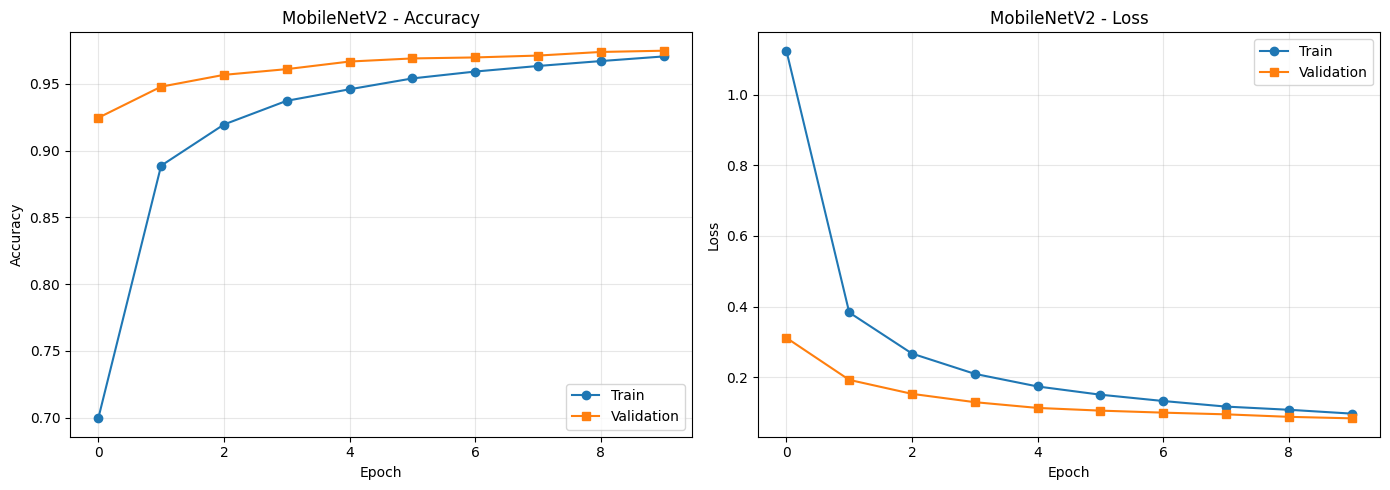

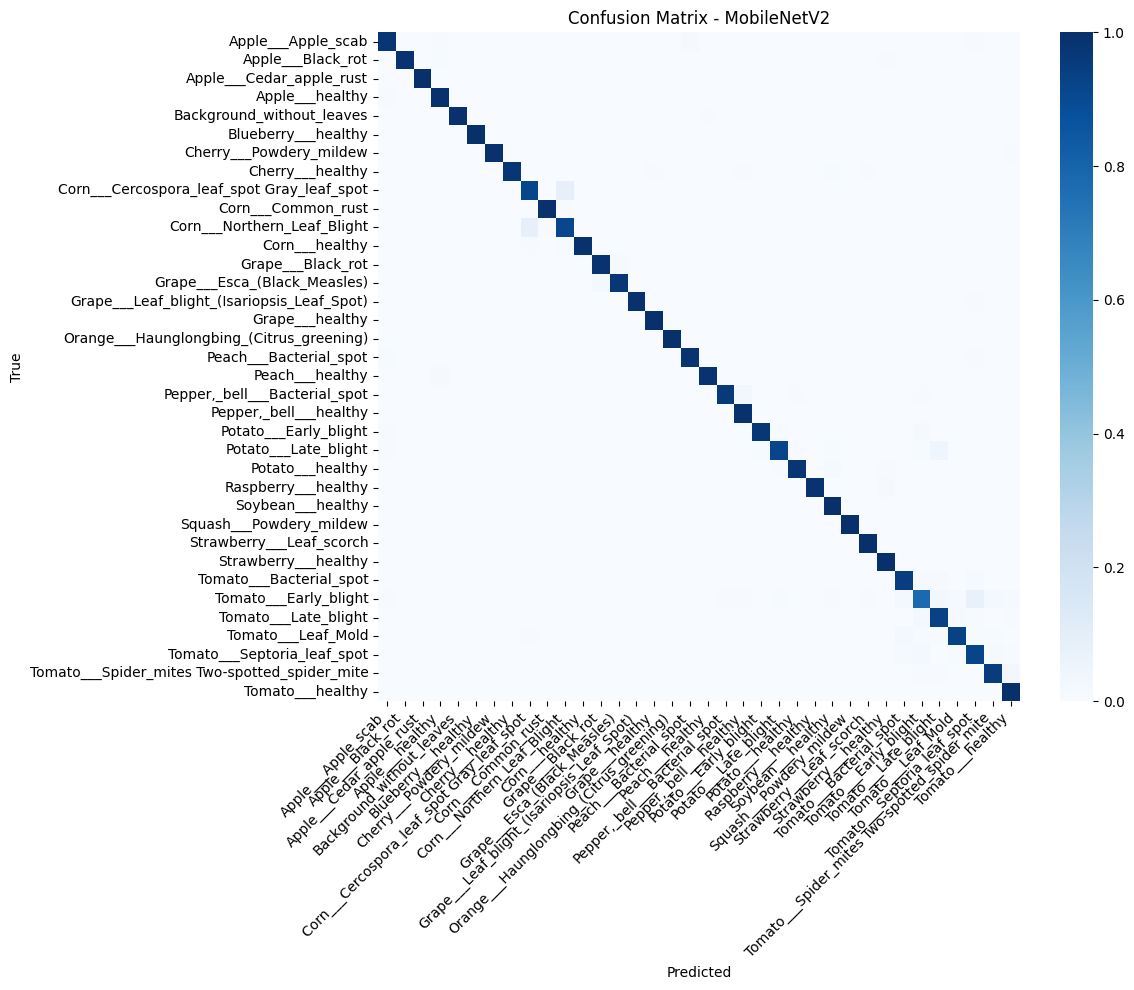


Classification Report - MobileNetV2
                                               precision    recall  f1-score   support

                           Apple___Apple_scab     0.9453    0.9744    0.9596       195
                            Apple___Black_rot     0.9906    0.9860    0.9883       214
                     Apple___Cedar_apple_rust     0.9952    1.0000    0.9976       206
                              Apple___healthy     0.9799    0.9884    0.9841       345
                    Background_without_leaves     0.9956    0.9956    0.9956       227
                          Blueberry___healthy     0.9965    0.9965    0.9965       289
                      Cherry___Powdery_mildew     1.0000    0.9950    0.9975       201
                             Cherry___healthy     1.0000    0.9755    0.9876       204
   Corn___Cercospora_leaf_spot Gray_leaf_spot     0.9095    0.9178    0.9136       219
                           Corn___Common_rust     0.9957    0.9957    0.9957       231
     

In [ ]:
model_name = "MobileNetV2"
print(f"\n===== {model_name} =====")
mobilenet_model = build_model(model_name, num_classes)
history_mobilenet, time_mobilenet = train_model(mobilenet_model, train_ds, val_ds, model_name)
mobilenet_model.save(f"{MODEL_SAVE_DIR}/{model_name}.h5")

results = evaluate_model(mobilenet_model, val_ds)
plot_training_history(history_mobilenet, model_name)
generate_confusion_matrix(results['confusion_matrix'], class_names, model_name)
generate_classification_report(results['y_true'], results['y_pred'], class_names, model_name)

histories[model_name] = history_mobilenet
trained_models[model_name] = mobilenet_model
training_times[model_name] = time_mobilenet
all_results[model_name] = results
append_comparison_row(model_name, mobilenet_model, results, time_mobilenet)

print(f"{model_name} -> Val Acc: {results['accuracy']:.4f} | Balanced: {results['balanced_accuracy']:.4f} | F1(w): {results['f1_score']:.4f}")
print(f"Saved: {MODEL_SAVE_DIR}/{model_name}.h5")

## 6. ResNet50


===== ResNet50 =====
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training ResNet50...
Epoch 1/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 185s 96ms/step - accuracy: 0.7788 - loss: 0.8423 - val_accuracy: 0.9642 - val_loss: 0.1648
Epoch 2/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 165s 92ms/step - accuracy: 0.9377 - loss: 0.2244 - val_accuracy: 0.9778 - val_loss: 0.0923
Epoch 3/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 156s 87ms/step - accuracy: 0.9596 - loss: 0.1428 - val_accuracy: 0.9822 - val_loss: 0.0687
Epoch 4/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 155s 87ms/step - accuracy: 0.9700 - loss: 0.1045 - val_accuracy: 0.9861 - val_loss: 0.0560
Epoch 5/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 202s 87ms/step - accuracy: 0.9767 - loss: 0.0812 - val_accuracy: 0.9873 - val_loss: 0.0464
Epoch 6/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 155s 87ms/step - accuracy: 0.9801 - loss: 0.0674 - val_accuracy: 0.9895 - val_loss: 0.0417
Epoch 7/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 155s 87ms/step - accuracy: 0.9836 - loss: 0.0563 - val_accuracy: 0

Training completed
ResNet50 training time: 27.49 minutes


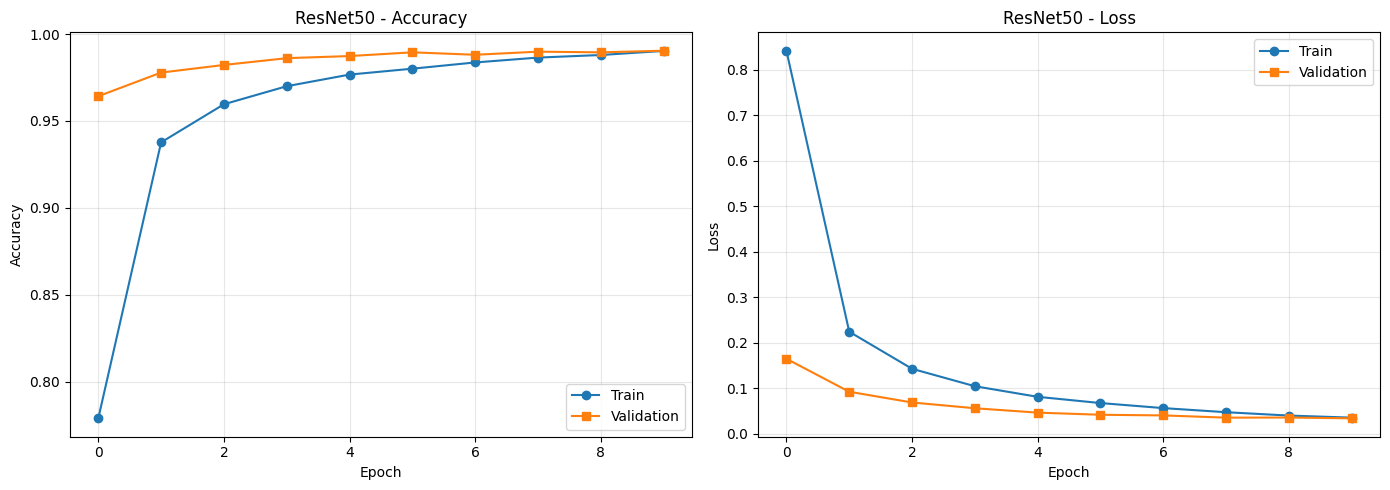

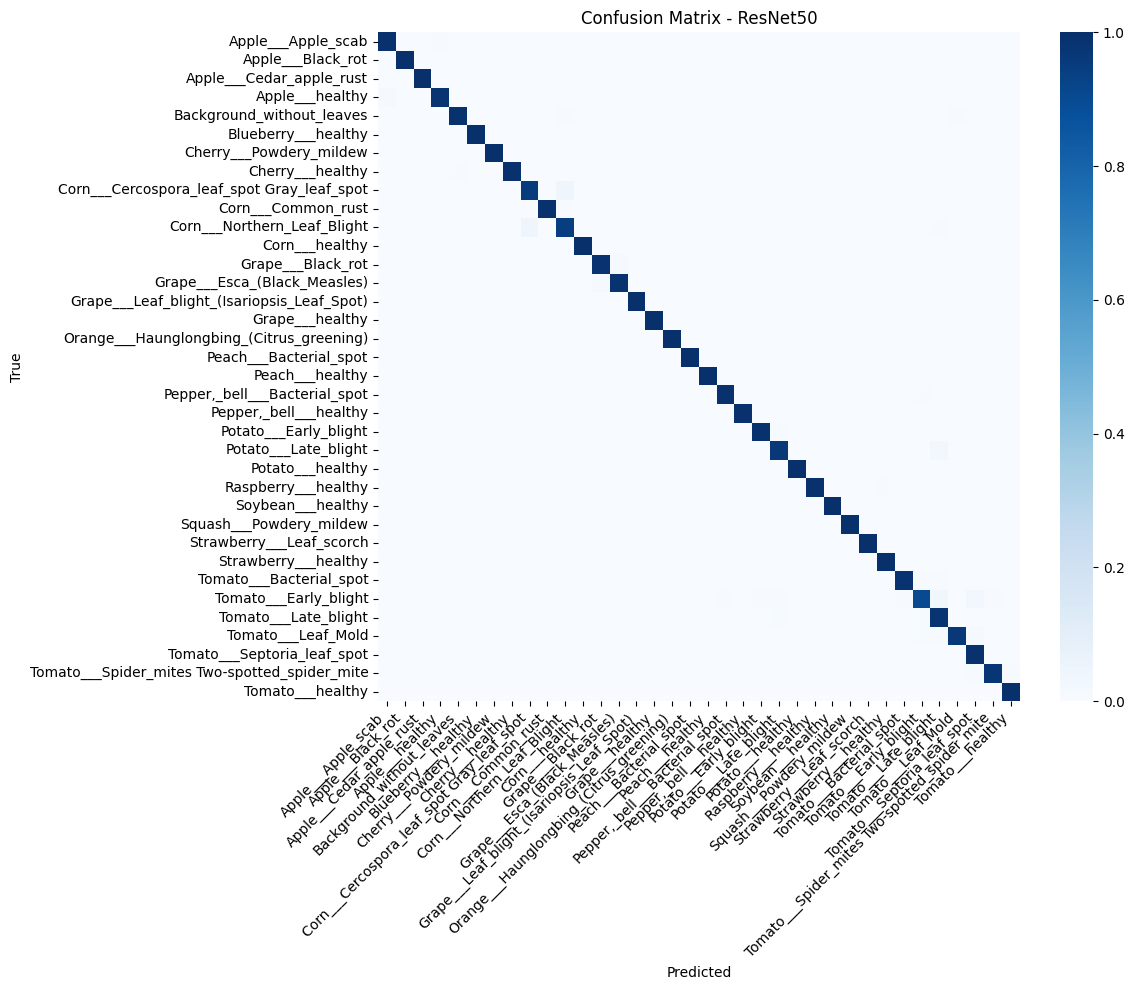


Classification Report - ResNet50
                                               precision    recall  f1-score   support

                           Apple___Apple_scab     0.9700    0.9949    0.9823       195
                            Apple___Black_rot     0.9953    1.0000    0.9977       214
                     Apple___Cedar_apple_rust     0.9952    1.0000    0.9976       206
                              Apple___healthy     0.9941    0.9826    0.9883       345
                    Background_without_leaves     0.9912    0.9912    0.9912       227
                          Blueberry___healthy     1.0000    0.9965    0.9983       289
                      Cherry___Powdery_mildew     1.0000    1.0000    1.0000       201
                             Cherry___healthy     1.0000    0.9951    0.9975       204
   Corn___Cercospora_leaf_spot Gray_leaf_spot     0.9543    0.9543    0.9543       219
                           Corn___Common_rust     1.0000    0.9957    0.9978       231
        

In [38]:
model_name = "ResNet50"
print(f"\n===== {model_name} =====")
resnet_model = build_model(model_name, num_classes)
history_resnet, time_resnet = train_model(resnet_model, train_ds, val_ds, model_name)
resnet_model.save(f"{MODEL_SAVE_DIR}/{model_name}.h5")

results = evaluate_model(resnet_model, val_ds)
plot_training_history(history_resnet, model_name)
generate_confusion_matrix(results['confusion_matrix'], class_names, model_name)
generate_classification_report(results['y_true'], results['y_pred'], class_names, model_name)

histories[model_name] = history_resnet
trained_models[model_name] = resnet_model
training_times[model_name] = time_resnet
all_results[model_name] = results
append_comparison_row(model_name, resnet_model, results, time_resnet)

print(f"{model_name} -> Val Acc: {results['accuracy']:.4f} | Balanced: {results['balanced_accuracy']:.4f} | F1(w): {results['f1_score']:.4f}")
print(f"Saved: {MODEL_SAVE_DIR}/{model_name}.h5")

## 7. VGG16


===== VGG16 =====
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training VGG16...
Epoch 1/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 411s 222ms/step - accuracy: 0.5103 - loss: 2.0237 - val_accuracy: 0.8638 - val_loss: 0.5516
Epoch 2/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 381s 213ms/step - accuracy: 0.7944 - loss: 0.6982 - val_accuracy: 0.9207 - val_loss: 0.2918
Epoch 3/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 382s 214ms/step - accuracy: 0.8613 - loss: 0.4512 - val_accuracy: 0.9415 - val_loss: 0.2097
Epoch 4/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 380s 213ms/step - accuracy: 0.8937 - loss: 0.3414 - val_accuracy: 0.9530 - val_loss: 0.1655
Epoch 5/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 382s 214ms/step - accuracy: 0.9156 - loss: 0.2706 - val_accuracy: 0.9593 - val_loss: 0.1407
Epoch 6/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 381s 213ms/step - accuracy: 0.9266 - loss: 0.2329 - val_accuracy: 0.9620 - val_loss: 0.1253
Epoch 7/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 382s 213ms/step - accuracy: 0.9369 - loss: 0.1991 - val_accuracy: 

Training completed
VGG16 training time: 64.01 minutes


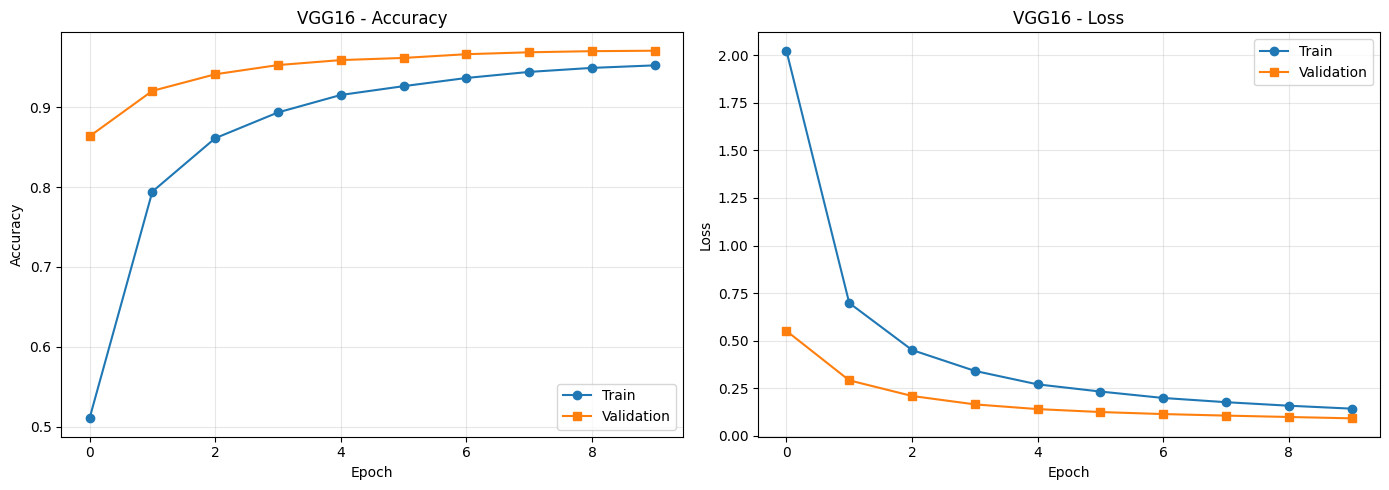

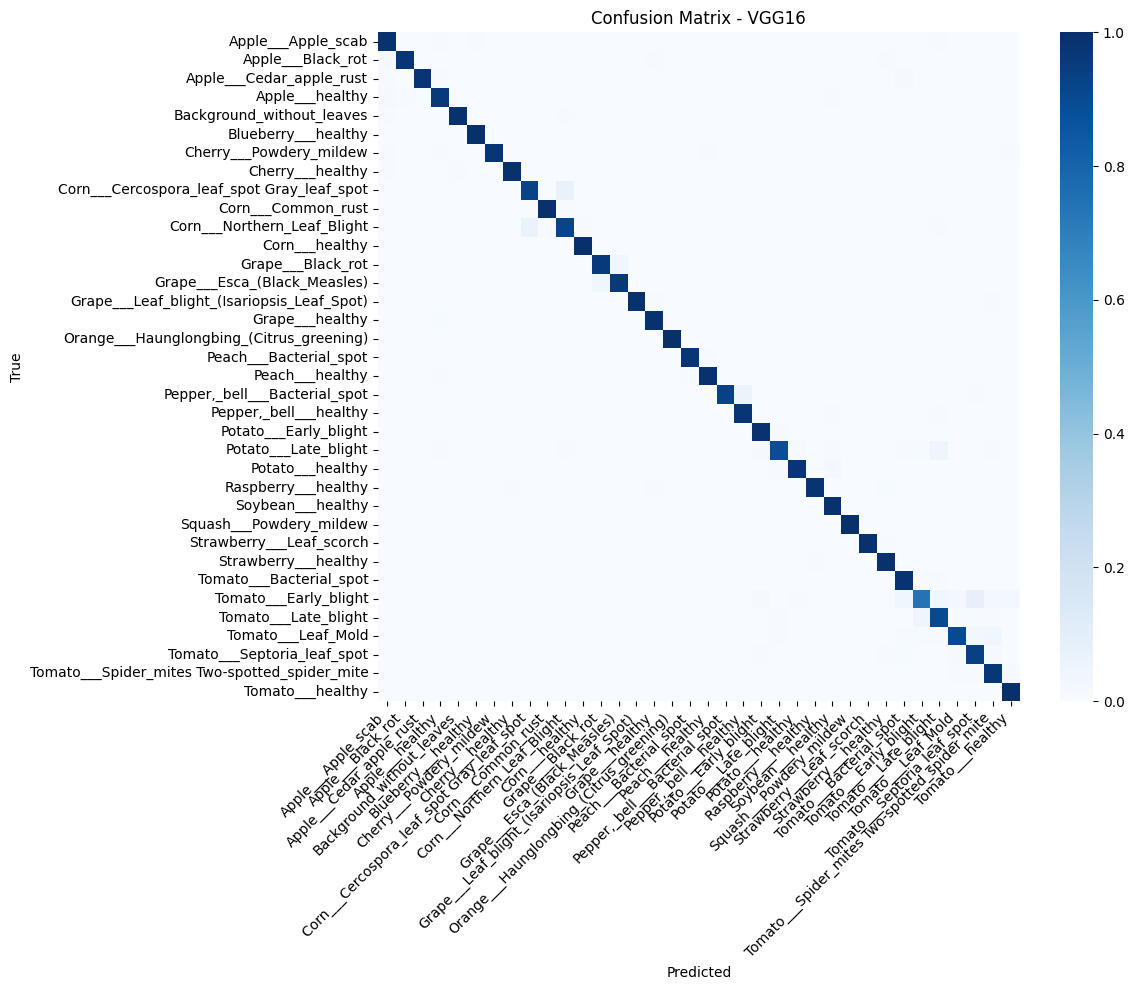


Classification Report - VGG16
                                               precision    recall  f1-score   support

                           Apple___Apple_scab     0.9366    0.9846    0.9600       195
                            Apple___Black_rot     0.9766    0.9766    0.9766       214
                     Apple___Cedar_apple_rust     0.9950    0.9757    0.9853       206
                              Apple___healthy     0.9650    0.9594    0.9622       345
                    Background_without_leaves     0.9868    0.9912    0.9890       227
                          Blueberry___healthy     0.9965    0.9965    0.9965       289
                      Cherry___Powdery_mildew     1.0000    0.9801    0.9899       201
                             Cherry___healthy     0.9854    0.9902    0.9878       204
   Corn___Cercospora_leaf_spot Gray_leaf_spot     0.9398    0.9269    0.9333       219
                           Corn___Common_rust     0.9957    0.9957    0.9957       231
           

In [39]:
model_name = "VGG16"
print(f"\n===== {model_name} =====")
vgg_model = build_model(model_name, num_classes)
history_vgg, time_vgg = train_model(vgg_model, train_ds, val_ds, model_name)
vgg_model.save(f"{MODEL_SAVE_DIR}/{model_name}.h5")

results = evaluate_model(vgg_model, val_ds)
plot_training_history(history_vgg, model_name)
generate_confusion_matrix(results['confusion_matrix'], class_names, model_name)
generate_classification_report(results['y_true'], results['y_pred'], class_names, model_name)

histories[model_name] = history_vgg
trained_models[model_name] = vgg_model
training_times[model_name] = time_vgg
all_results[model_name] = results
append_comparison_row(model_name, vgg_model, results, time_vgg)

print(f"{model_name} -> Val Acc: {results['accuracy']:.4f} | Balanced: {results['balanced_accuracy']:.4f} | F1(w): {results['f1_score']:.4f}")
print(f"Saved: {MODEL_SAVE_DIR}/{model_name}.h5")

## 8. EfficientNetB0


===== EfficientNetB0 =====
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training EfficientNetB0...
Epoch 1/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 122s 54ms/step - accuracy: 0.7061 - loss: 1.1681 - val_accuracy: 0.9346 - val_loss: 0.3256
Epoch 2/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 98s 38ms/step - accuracy: 0.8976 - loss: 0.3838 - val_accuracy: 0.9597 - val_loss: 0.1791
Epoch 3/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 67s 37ms/step - accuracy: 0.9291 - loss: 0.2536 - val_accuracy: 0.9692 - val_loss: 0.1270
Epoch 4/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 68s 38ms/step - accuracy: 0.9448 - loss: 0.1936 - val_accuracy: 0.9735 - val_loss: 0.1033
Epoch 5/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 68s 38ms/step - accuracy: 0.9536 - loss: 0.1605 - val_accuracy: 0.9791 - val_loss: 0.0860
Epoch 6/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 75s 42ms/step - accuracy: 0.9625 - loss: 0.1335 - val_accuracy: 0.9800 - val_loss: 0.0746
Epoch 7/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 75s 42ms/step - accuracy: 0.9658 - loss: 0.1168 - val_accur

Training completed
EfficientNetB0 training time: 13.17 minutes


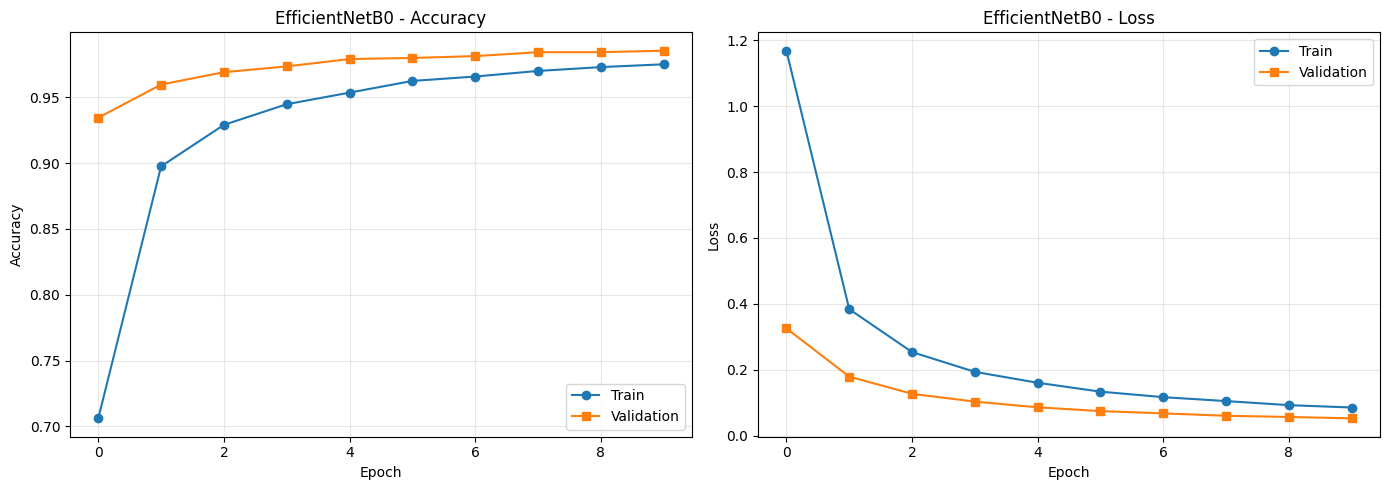

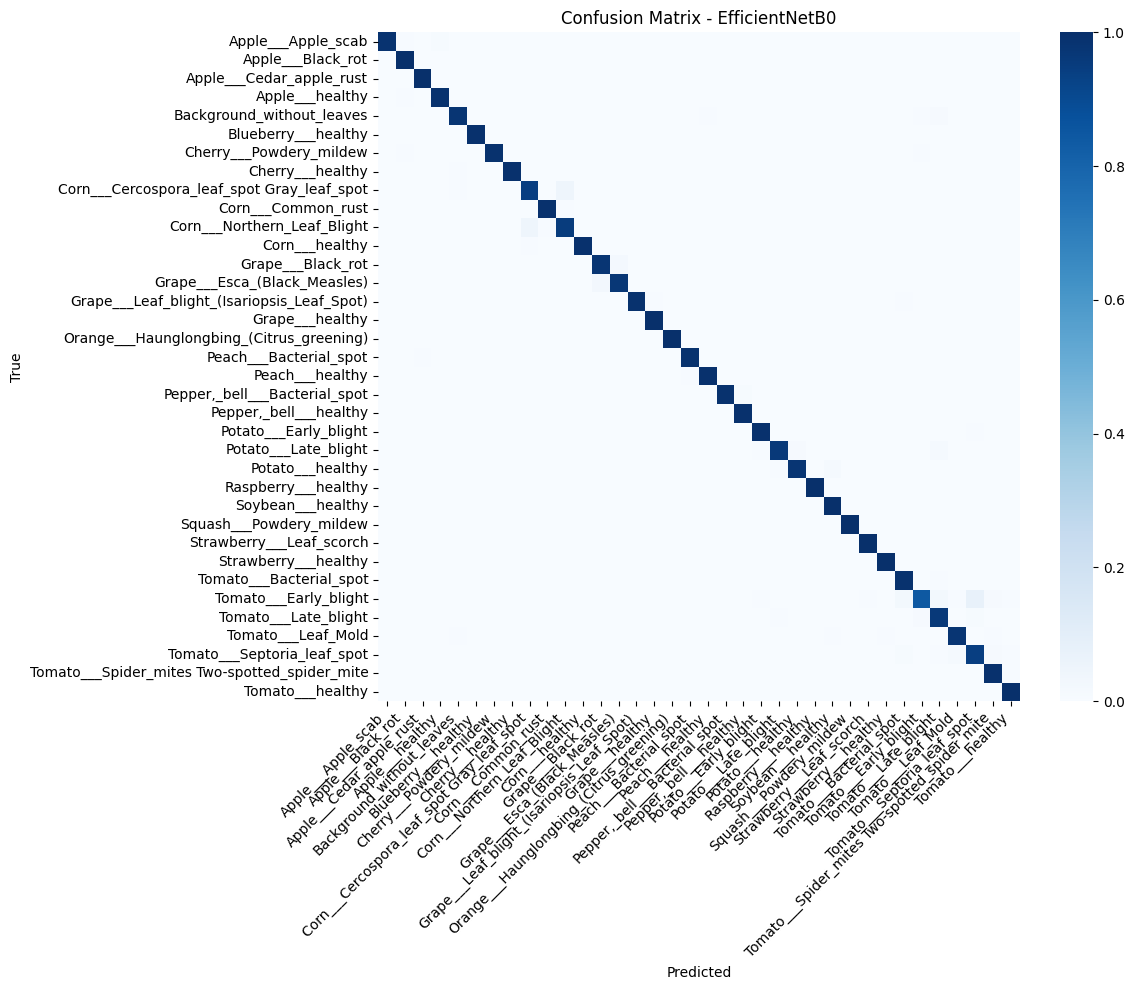


Classification Report - EfficientNetB0
                                               precision    recall  f1-score   support

                           Apple___Apple_scab     0.9897    0.9846    0.9871       195
                            Apple___Black_rot     0.9817    1.0000    0.9907       214
                     Apple___Cedar_apple_rust     0.9904    1.0000    0.9952       206
                              Apple___healthy     0.9913    0.9913    0.9913       345
                    Background_without_leaves     0.9867    0.9780    0.9823       227
                          Blueberry___healthy     1.0000    0.9931    0.9965       289
                      Cherry___Powdery_mildew     1.0000    0.9900    0.9950       201
                             Cherry___healthy     1.0000    0.9951    0.9975       204
   Corn___Cercospora_leaf_spot Gray_leaf_spot     0.9539    0.9452    0.9495       219
                           Corn___Common_rust     0.9957    0.9957    0.9957       231
  

In [40]:
model_name = "EfficientNetB0"
print(f"\n===== {model_name} =====")
efficientnet_model = build_model(model_name, num_classes)
history_efficientnet, time_efficientnet = train_model(efficientnet_model, train_ds, val_ds, model_name)
efficientnet_model.save(f"{MODEL_SAVE_DIR}/{model_name}.h5")

results = evaluate_model(efficientnet_model, val_ds)
plot_training_history(history_efficientnet, model_name)
generate_confusion_matrix(results['confusion_matrix'], class_names, model_name)
generate_classification_report(results['y_true'], results['y_pred'], class_names, model_name)

histories[model_name] = history_efficientnet
trained_models[model_name] = efficientnet_model
training_times[model_name] = time_efficientnet
all_results[model_name] = results
append_comparison_row(model_name, efficientnet_model, results, time_efficientnet)

print(f"{model_name} -> Val Acc: {results['accuracy']:.4f} | Balanced: {results['balanced_accuracy']:.4f} | F1(w): {results['f1_score']:.4f}")
print(f"Saved: {MODEL_SAVE_DIR}/{model_name}.h5")

## 9. DenseNet121


===== DenseNet121 =====
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training DenseNet121...
Epoch 1/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 203s 98ms/step - accuracy: 0.6347 - loss: 1.3863 - val_accuracy: 0.9179 - val_loss: 0.4065
Epoch 2/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 149s 78ms/step - accuracy: 0.8676 - loss: 0.4721 - val_accuracy: 0.9497 - val_loss: 0.2179
Epoch 3/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 138s 77ms/step - accuracy: 0.9105 - loss: 0.3094 - val_accuracy: 0.9608 - val_loss: 0.1587
Epoch 4/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 142s 77ms/step - accuracy: 0.9328 - loss: 0.2317 - val_accuracy: 0.9651 - val_loss: 0.1265
Epoch 5/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 152s 85ms/step - accuracy: 0.9426 - loss: 0.1911 - val_accuracy: 0.9707 - val_loss: 0.1084
Epoch 6/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 139s 78ms/step - accuracy: 0.9515 - loss: 0.1610 - val_accuracy: 0.9741 - val_loss: 0.0945
Epoch 7/10
1789/1789 ━━━━━━━━━━━━━━━━━━━━ 152s 85ms/step - accuracy: 0.9588 - loss: 0.1392 - val_accur

Training completed
DenseNet121 training time: 25.18 minutes


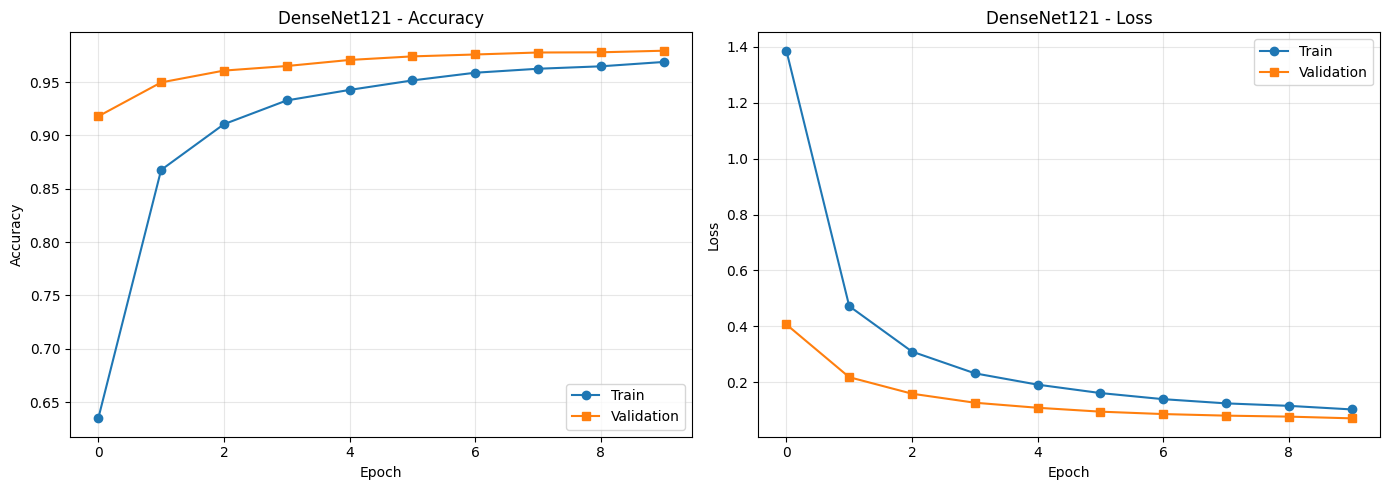

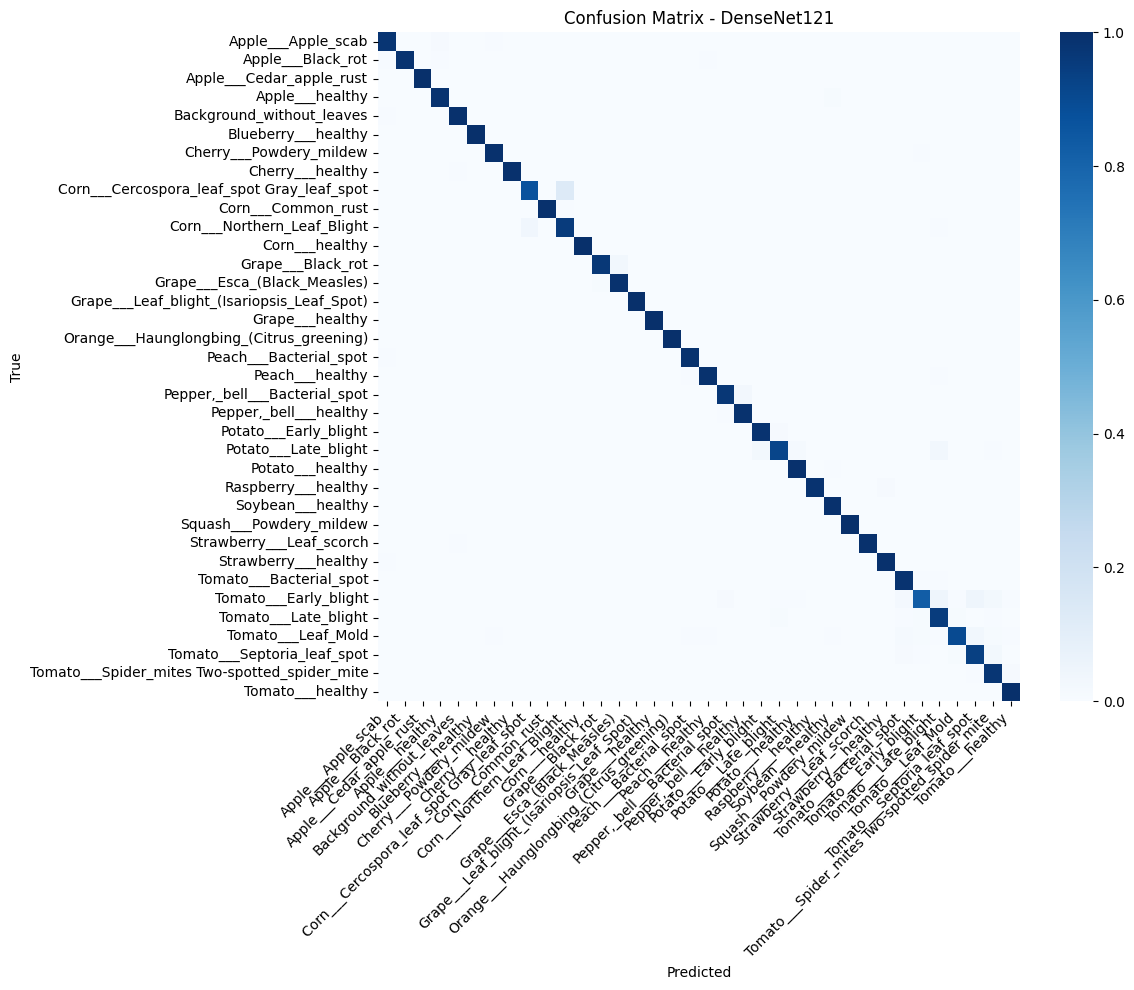


Classification Report - DenseNet121
                                               precision    recall  f1-score   support

                           Apple___Apple_scab     0.9646    0.9795    0.9720       195
                            Apple___Black_rot     0.9953    0.9860    0.9906       214
                     Apple___Cedar_apple_rust     1.0000    1.0000    1.0000       206
                              Apple___healthy     0.9798    0.9855    0.9827       345
                    Background_without_leaves     0.9869    0.9956    0.9912       227
                          Blueberry___healthy     0.9966    1.0000    0.9983       289
                      Cherry___Powdery_mildew     0.9901    0.9950    0.9926       201
                             Cherry___healthy     0.9951    0.9951    0.9951       204
   Corn___Cercospora_leaf_spot Gray_leaf_spot     0.9596    0.8676    0.9113       219
                           Corn___Common_rust     0.9957    0.9957    0.9957       231
     

In [41]:
model_name = "DenseNet121"
print(f"\n===== {model_name} =====")
densenet_model = build_model(model_name, num_classes)
history_densenet, time_densenet = train_model(densenet_model, train_ds, val_ds, model_name)
densenet_model.save(f"{MODEL_SAVE_DIR}/{model_name}.h5")

results = evaluate_model(densenet_model, val_ds)
plot_training_history(history_densenet, model_name)
generate_confusion_matrix(results['confusion_matrix'], class_names, model_name)
generate_classification_report(results['y_true'], results['y_pred'], class_names, model_name)

histories[model_name] = history_densenet
trained_models[model_name] = densenet_model
training_times[model_name] = time_densenet
all_results[model_name] = results
append_comparison_row(model_name, densenet_model, results, time_densenet)

print(f"{model_name} -> Val Acc: {results['accuracy']:.4f} | Balanced: {results['balanced_accuracy']:.4f} | F1(w): {results['f1_score']:.4f}")
print(f"Saved: {MODEL_SAVE_DIR}/{model_name}.h5")

## 10. Final Comparison (Same as Previous Style)

In [42]:
comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(by="Val Accuracy", ascending=False).reset_index(drop=True)

print("\n" + "=" * 90)
print("COMPARATIVE STUDY - MODEL PERFORMANCE SUMMARY")
print("=" * 90)
print(comparison_df.to_string(index=False))
print("=" * 90)

comparison_df.to_csv(f"{MODEL_SAVE_DIR}/comparison_table.csv", index=False)
print(f"Saved comparison table: {MODEL_SAVE_DIR}/comparison_table.csv")


COMPARATIVE STUDY - MODEL PERFORMANCE SUMMARY
         Model  Val Accuracy  Balanced Acc  Precision (w)  Recall (w)   F1 (w)  Precision (macro)  Recall (macro)  F1 (macro)      MCC  Training Time (min)  Training Time (s)  Parameters
      ResNet50      0.990402      0.988294       0.990492    0.990402 0.990401           0.988922        0.988294    0.988558 0.990009            27.494354        1649.661265    24121508
EfficientNetB0      0.985463      0.982575       0.985430    0.985463 0.985369           0.983629        0.982575    0.982995 0.984867            13.167964         790.077853     4386759
   DenseNet121      0.979405      0.974903       0.979546    0.979405 0.979265           0.976808        0.974903    0.975563 0.978565            25.177705        1510.662276     7309156
   MobileNetV2      0.974746      0.969983       0.974754    0.974746 0.974670           0.971407        0.969983    0.970598 0.973708            13.019886         781.193149     2595172
         VGG16    

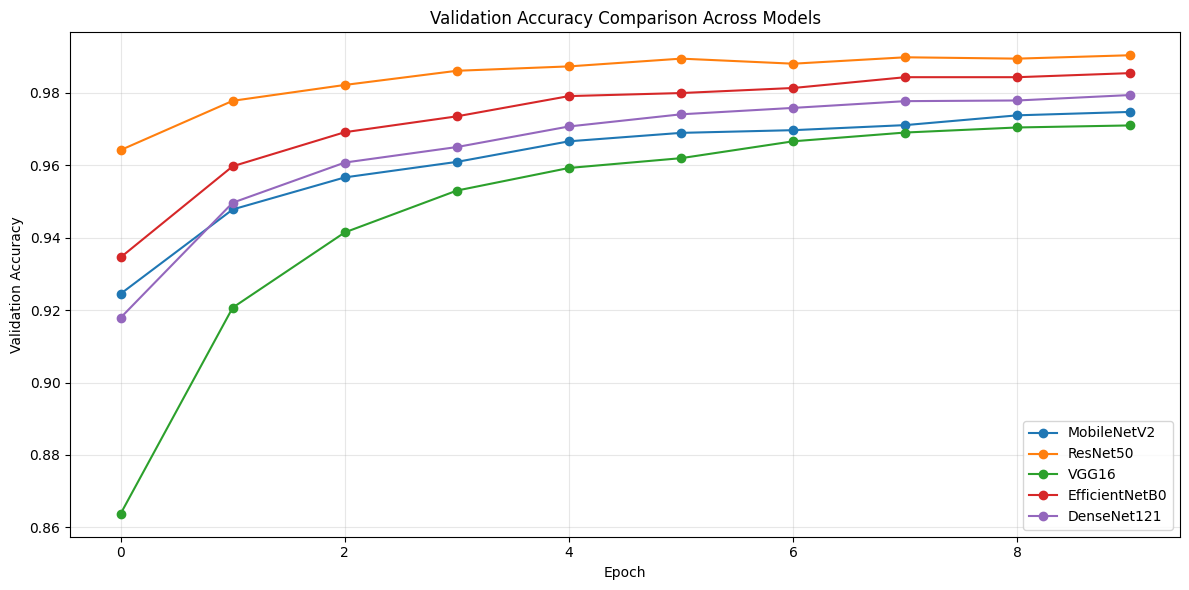

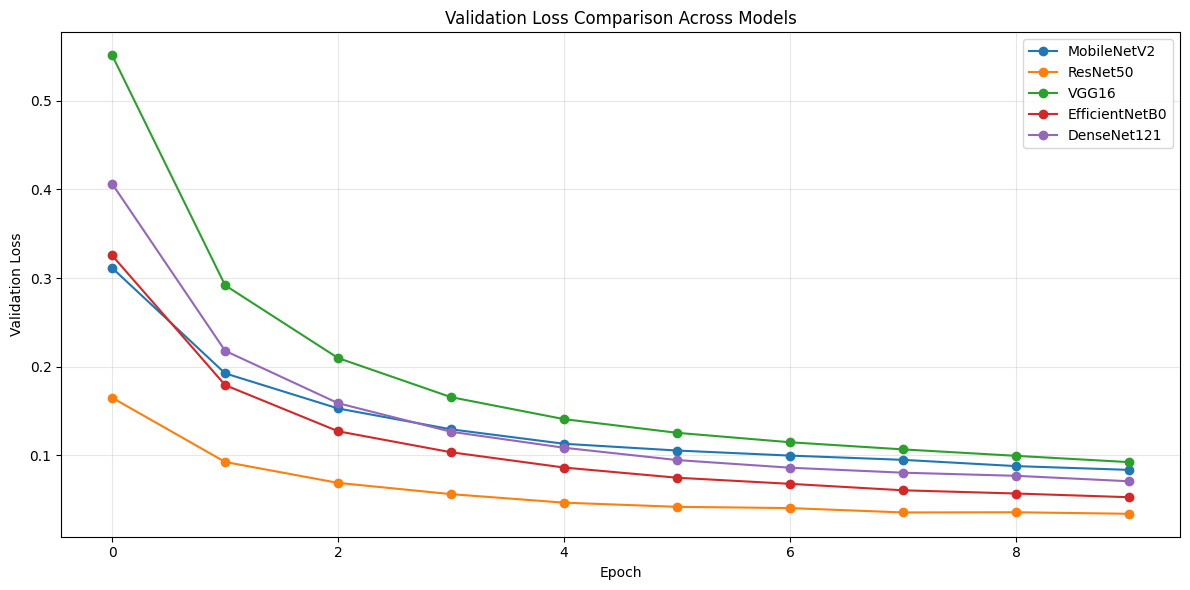

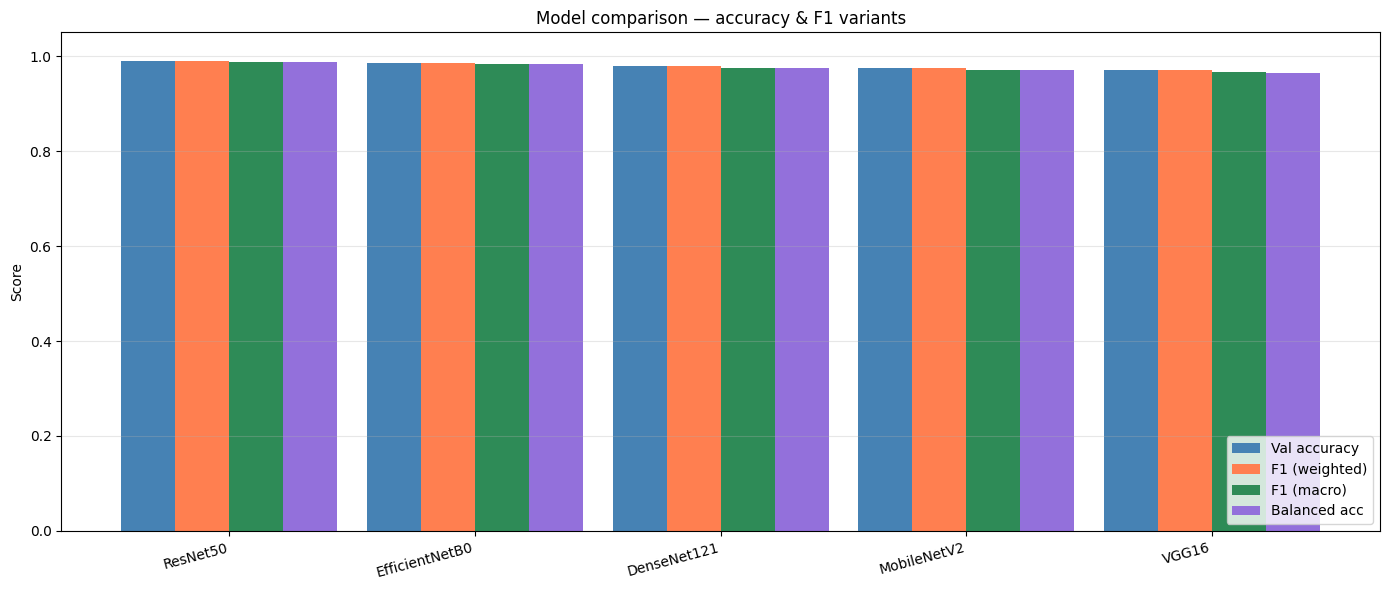

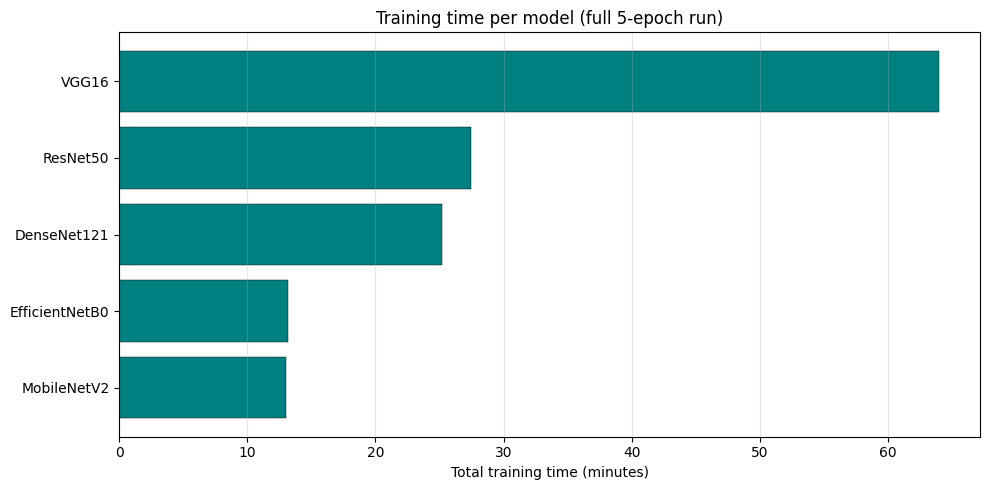

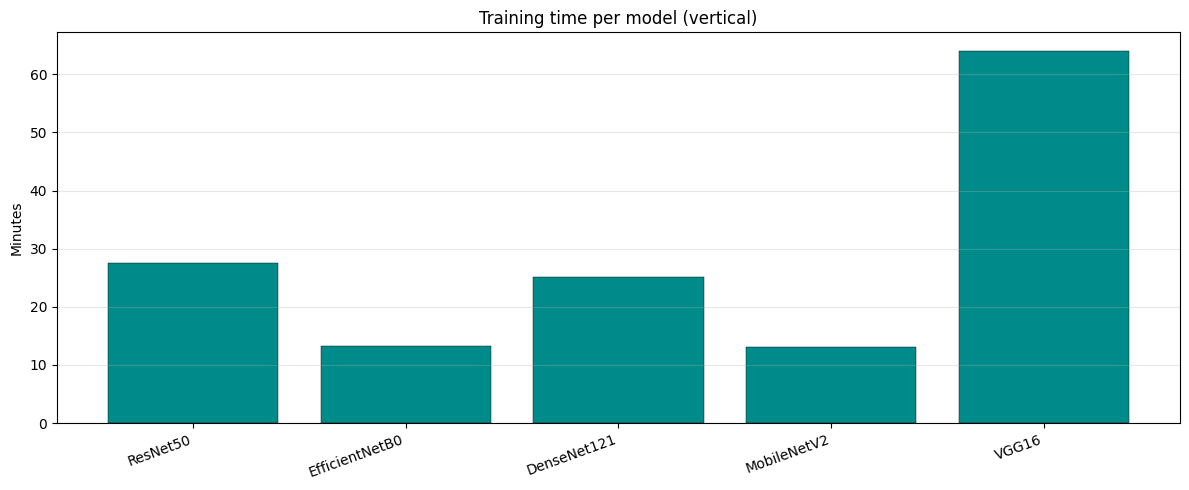

In [43]:
plt.figure(figsize=(12, 6))
for model_name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=model_name, marker='o')

plt.title('Validation Accuracy Comparison Across Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_SAVE_DIR}/val_accuracy_all_models.png", dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))
for model_name, history in histories.items():
    plt.plot(history.history['val_loss'], label=model_name, marker='o')

plt.title('Validation Loss Comparison Across Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_SAVE_DIR}/val_loss_all_models.png", dpi=150, bbox_inches='tight')
plt.show()

model_names = list(comparison_df['Model'])
accuracies = list(comparison_df['Val Accuracy'])
f1_w = list(comparison_df['F1 (w)'])
f1_macro = list(comparison_df['F1 (macro)'])
bal_acc = list(comparison_df['Balanced Acc'])

x = np.arange(len(model_names))
width = 0.22

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, accuracies, width, label='Val accuracy', color='steelblue')
ax.bar(x, f1_w, width, label='F1 (weighted)', color='coral')
ax.bar(x + width, f1_macro, width, label='F1 (macro)', color='seagreen')
ax.bar(x + 2 * width, bal_acc, width, label='Balanced acc', color='mediumpurple')

ax.set_title('Model comparison — accuracy & F1 variants')
ax.set_ylabel('Score')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_SAVE_DIR}/bar_metrics_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Training time (minutes) — horizontal bar
times_min = list(comparison_df['Training Time (min)'])
fig, ax = plt.subplots(figsize=(10, 5))
order = np.argsort(times_min)
ax.barh([model_names[i] for i in order], [times_min[i] for i in order], color='teal', edgecolor='black', linewidth=0.3)
ax.set_xlabel('Total training time (minutes)')
ax.set_title('Training time per model (full 5-epoch run)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_SAVE_DIR}/training_time_barh.png", dpi=150, bbox_inches='tight')
plt.show()

# Training time — vertical bar (same data, presentation alternative)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(model_names, times_min, color='darkcyan', edgecolor='black', linewidth=0.3)
ax.set_ylabel('Minutes')
ax.set_title('Training time per model (vertical)')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(f"{MODEL_SAVE_DIR}/training_time_barv.png", dpi=150, bbox_inches='tight')
plt.show()

### Extra comparison visuals

Heatmap of core metrics, Matthews correlation coefficient (MCC) per model, radar overlay, and accuracy vs training time.

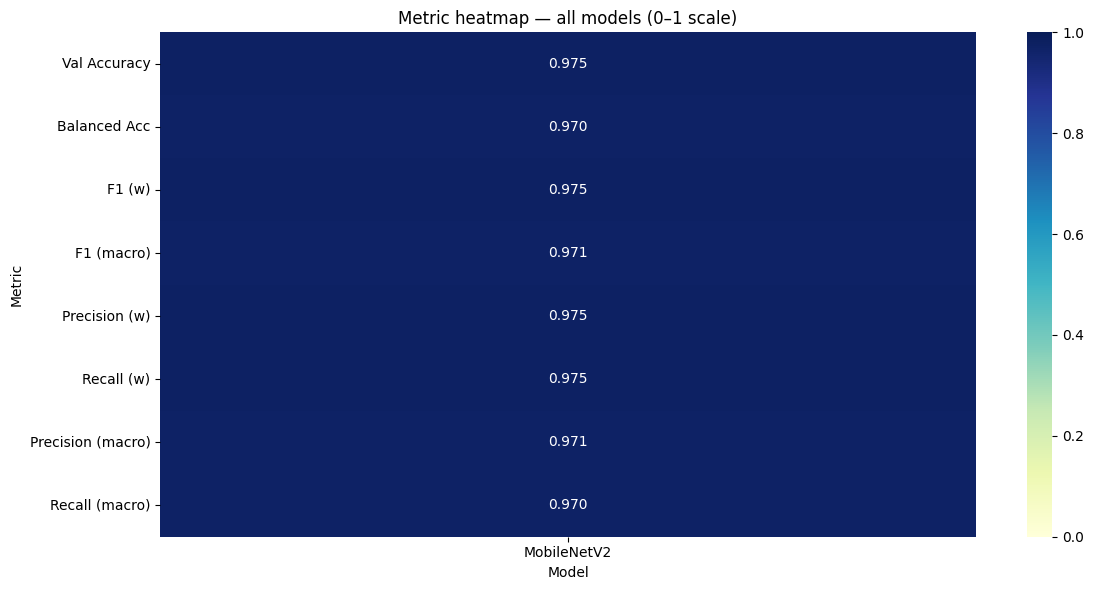

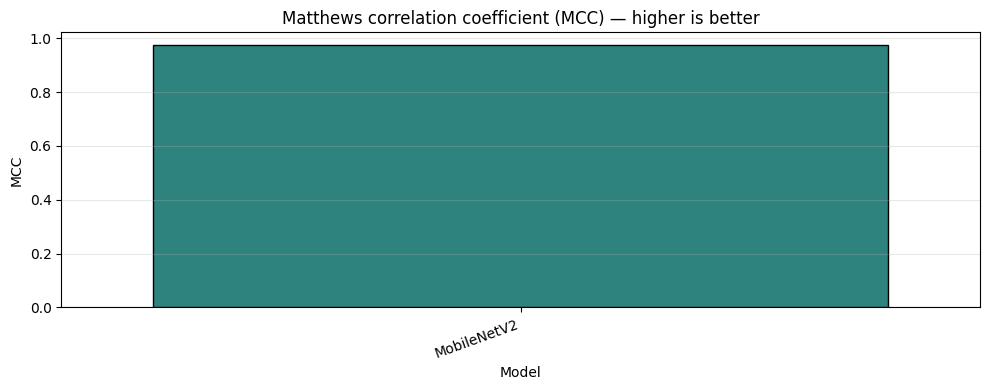

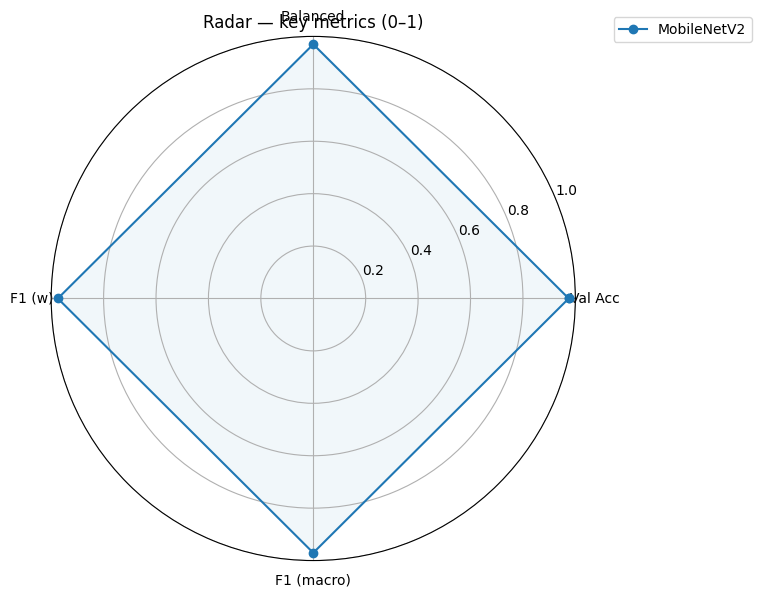

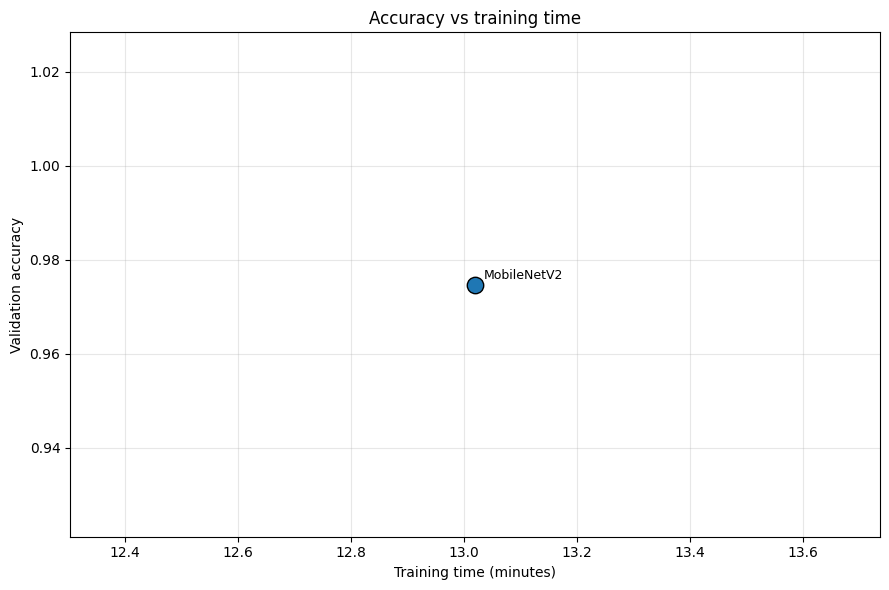

In [ ]:
# Heatmap: metrics in [0, 1] range (good for side-by-side comparison)
metric_cols_01 = [
    "Val Accuracy",
    "Balanced Acc",
    "F1 (w)",
    "F1 (macro)",
    "Precision (w)",
    "Recall (w)",
    "Precision (macro)",
    "Recall (macro)",
]
hm_data = comparison_df.set_index("Model")[metric_cols_01].T

plt.figure(figsize=(12, 6))
sns.heatmap(hm_data, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Metric heatmap — all models (0–1 scale)")
plt.ylabel("Metric")
plt.tight_layout()
plt.savefig(f"{MODEL_SAVE_DIR}/metrics_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# MCC (can be negative; shown separately)
plt.figure(figsize=(10, 4))
sns.barplot(x="Model", y="MCC", data=comparison_df, palette="viridis", edgecolor="black")
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Matthews correlation coefficient (MCC) — higher is better")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_SAVE_DIR}/mcc_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

# Radar chart: four main scores per model
labels_r = ["Val Acc", "Balanced", "F1 (w)", "F1 (macro)"]
n_ax = len(labels_r)
angles = np.linspace(0, 2 * np.pi, n_ax, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for _, row in comparison_df.iterrows():
    vals = [
        row["Val Accuracy"],
        row["Balanced Acc"],
        row["F1 (w)"],
        row["F1 (macro)"],
    ]
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=1.5, label=row["Model"])
    ax.fill(angles, vals, alpha=0.06)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_r)
ax.set_ylim(0, 1)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.05))
plt.title("Radar — key metrics (0–1)")
plt.tight_layout()
plt.savefig(f"{MODEL_SAVE_DIR}/radar_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

# Trade-off: accuracy vs training cost
plt.figure(figsize=(9, 6))
plt.scatter(
    comparison_df["Training Time (min)"],
    comparison_df["Val Accuracy"],
    s=140,
    c=range(len(comparison_df)),
    cmap="tab10",
    edgecolors="black",
)
for _, row in comparison_df.iterrows():
    plt.annotate(
        row["Model"],
        (row["Training Time (min)"], row["Val Accuracy"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=9,
    )
plt.xlabel("Training time (minutes)")
plt.ylabel("Validation accuracy")
plt.title("Accuracy vs training time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_SAVE_DIR}/accuracy_vs_time.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Final Cell - Grad-CAM (MobileNetV2)

In [ ]:
import cv2

def _get_mobilenet_backbone(model):
    # The MobileNetV2 backbone is nested as a sub-model layer inside `build_model()`.
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and "mobilenetv2" in layer.name.lower():
            return layer
    raise ValueError("Could not find MobileNetV2 backbone sub-model in the model layers.")


def find_last_conv_layer(model):
    backbone = _get_mobilenet_backbone(model)
    conv_types = (tf.keras.layers.Conv2D, tf.keras.layers.DepthwiseConv2D)

    # Scan backbone layers from end to start to get the last conv-like layer
    for layer in reversed(backbone.layers):
        if isinstance(layer, conv_types):
            return layer.name

    raise ValueError("No convolutional layer found in MobileNetV2 backbone.")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Robust Grad-CAM for your trained MobileNetV2 classifier.

    Fix: compute gradients in a *connected* graph by:
    1) extracting target conv features
    2) running the remaining backbone
    3) running the classifier head

    This avoids Keras `KeyError` issues when using multi-output models.
    """
    backbone = _get_mobilenet_backbone(model)
    target_layer = backbone.get_layer(last_conv_layer_name)

    preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input
    x = preprocess_fn(img_array)

    # Extractors
    target_extractor = tf.keras.Model(
        inputs=backbone.input,
        outputs=target_layer.output,
    )
    tail_extractor = tf.keras.Model(
        inputs=target_layer.output,
        outputs=backbone.output,
    )
    head_extractor = tf.keras.Model(
        inputs=backbone.output,
        outputs=model.output,
    )

    with tf.GradientTape() as tape:
        conv_output = target_extractor(x, training=False)
        backbone_features = tail_extractor(conv_output, training=False)
        preds = head_extractor(backbone_features, training=False)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])

        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]  # (H, W, C)
    heatmap = tf.reduce_sum(conv_output * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Load trained MobileNetV2 model WITHOUT deserializing custom layers
# (fixes errors like: Unknown layer: 'TrueDivide')
mobile_model_path = f"{MODEL_SAVE_DIR}/MobileNetV2.h5"

mobile_model = build_model("MobileNetV2", num_classes)
mobile_model.load_weights(mobile_model_path)

# Select last convolutional layer automatically
last_conv_layer_name = find_last_conv_layer(mobile_model)
print("Last conv layer:", last_conv_layer_name)

# Load one sample image from validation dataset
for batch_images, batch_labels in val_ds.take(1):
    sample_image = batch_images[0].numpy().astype("uint8")
    sample_label = int(batch_labels[0].numpy())
    break

# Prepare image for model input
img_array = tf.expand_dims(tf.cast(sample_image, tf.float32), axis=0)

# Predict class using your trained model
preds = mobile_model(img_array, training=False)
pred_index = int(tf.argmax(preds[0]).numpy())
true_index = sample_label
print(f"Predicted class: {class_names[pred_index]}")
print(f"True class: {class_names[true_index]}")

# Generate heatmap for the predicted class
heatmap = make_gradcam_heatmap(img_array, mobile_model, last_conv_layer_name, pred_index=pred_index)

# Overlay heatmap on original image
heatmap_resized = cv2.resize(heatmap, (sample_image.shape[1], sample_image.shape[0]))
heatmap_uint8 = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
overlay = cv2.addWeighted(cv2.cvtColor(sample_image, cv2.COLOR_RGB2BGR), 0.6, heatmap_color, 0.4, 0)
overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.imshow(sample_image)
plt.title(f"Original\nTrue: {class_names[true_index]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

Last conv layer: Conv_1
Predicted class: Strawberry___healthy
True class: Strawberry___healthy


ValueError: `inputs` not connected to `outputs`

## 12. XAI — Grad-CAM heatmap (MobileNetV2)

**Explainable AI:** Grad-CAM highlights image regions that most influenced the model’s prediction. Uses your saved `MobileNetV2.h5` weights (no retraining).

In [ ]:


import cv2

def _get_mobilenet_backbone(model):
    # The MobileNetV2 backbone is nested as a sub-model layer inside `build_model()`.
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and "mobilenetv2" in layer.name.lower():
            return layer
    raise ValueError("Could not find MobileNetV2 backbone sub-model in the model layers.")


def find_last_conv_layer(model):
    backbone = _get_mobilenet_backbone(model)
    conv_types = (tf.keras.layers.Conv2D, tf.keras.layers.DepthwiseConv2D)

    # Scan backbone layers from end to start to get the last conv-like layer
    for layer in reversed(backbone.layers):
        if isinstance(layer, conv_types):
            return layer.name

    raise ValueError("No convolutional layer found in MobileNetV2 backbone.")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Robust Grad-CAM for your trained MobileNetV2 classifier.

    Fix: compute gradients in a *connected* graph by:
    1) extracting target conv features
    2) running the remaining backbone
    3) running the classifier head

    This avoids Keras `KeyError` issues when using multi-output models.
    """
    backbone = _get_mobilenet_backbone(model)
    target_layer = backbone.get_layer(last_conv_layer_name)

    preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input
    x = preprocess_fn(img_array)

    # Extractors
    target_extractor = tf.keras.Model(
        inputs=backbone.input,
        outputs=target_layer.output,
    )
    tail_extractor = tf.keras.Model(
        inputs=target_layer.output,
        outputs=backbone.output,
    )
    head_extractor = tf.keras.Model(
        inputs=backbone.output,
        outputs=model.output,
    )

    with tf.GradientTape() as tape:
        conv_output = target_extractor(x, training=False)
        backbone_features = tail_extractor(conv_output, training=False)
        preds = head_extractor(backbone_features, training=False)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])

        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]  # (H, W, C)
    heatmap = tf.reduce_sum(conv_output * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Load trained MobileNetV2 model WITHOUT deserializing custom layers
# (fixes errors like: Unknown layer: 'TrueDivide')
mobile_model_path = f"{MODEL_SAVE_DIR}/MobileNetV2.h5"

mobile_model = build_model("MobileNetV2", num_classes)
mobile_model.load_weights(mobile_model_path)

# Select last convolutional layer automatically
last_conv_layer_name = find_last_conv_layer(mobile_model)
print("Last conv layer:", last_conv_layer_name)

# Load one sample image from validation dataset
for batch_images, batch_labels in val_ds.take(1):
    sample_image = batch_images[0].numpy().astype("uint8")
    sample_label = int(batch_labels[0].numpy())
    break

# Prepare image for model input
img_array = tf.expand_dims(tf.cast(sample_image, tf.float32), axis=0)

# Predict class using your trained model
preds = mobile_model(img_array, training=False)
pred_index = int(tf.argmax(preds[0]).numpy())
true_index = sample_label
print(f"Predicted class: {class_names[pred_index]}")
print(f"True class: {class_names[true_index]}")

# Generate heatmap for the predicted class
heatmap = make_gradcam_heatmap(img_array, mobile_model, last_conv_layer_name, pred_index=pred_index)

# Overlay heatmap on original image
heatmap_resized = cv2.resize(heatmap, (sample_image.shape[1], sample_image.shape[0]))
heatmap_uint8 = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
overlay = cv2.addWeighted(cv2.cvtColor(sample_image, cv2.COLOR_RGB2BGR), 0.6, heatmap_color, 0.4, 0)
overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.imshow(sample_image)
plt.title(f"Original\nTrue: {class_names[true_index]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("XAI — Grad-CAM heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay (image + heatmap)")
plt.axis("off")

plt.suptitle("Explainable AI (XAI): class-discriminative localization", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f"{MODEL_SAVE_DIR}/xai_gradcam_mobilenetv2.png", dpi=150, bbox_inches="tight")
plt.show()
